# מטלה בלמידת מכונה - סיווג הודעות ספאם 

## פרטי הסטודנטים
- רון ה. (6397)
- סתיו ב. (7651)

## פרטי הפרויקט

- סוג המטלה: Text / NLP
- סוג הלמידה: Classification
- Dataset: SMS Spam Collection - A More Diverse Dataset
- מטרה: לסווג הודעות SMS להודעות רגילות או הודעות ספאם

## 1. תיאור הבעיה

בפרויקט הזה אנחנו עובדים על בעיית סיווג טקסט.

המטרה היא לקחת הודעת SMS ולסווג אותה לאחת משתי מחלקות:

- `ham` — הודעה רגילה
- `spam` — הודעת ספאם

בדאטה סט המקורי התוויות הן:

- `0` — הודעה רגילה
- `1` — הודעת ספאם

זאת בעיית סיווג בינארית, כי יש רק שתי מחלקות אפשריות.

## 2. תיאור ה-Dataset

ה-Dataset מכיל הודעות SMS באנגלית, ולכל הודעה יש תווית שמציינת אם היא רגילה או ספאם.

הקובץ שבו השתמשנו נקרא `train.csv`.

יש בו שתי עמודות עיקריות:

- `sms` — הטקסט של ההודעה
- `label` — הסיווג של ההודעה

בהמשך העבודה שינינו את שם העמודה `sms` ל-`text`, והמרנו את התוויות:

- `0` ל-`ham`
- `1` ל-`spam`

עשינו את זה כדי שהעבודה עם הנתונים תהיה יותר ברורה.

## 3. שימוש בכלי AI

נעשה שימוש בכלי AI בעיקר כדי להבין את דרישות המטלה, לסדר את מבנה העבודה ולקבל עזרה בניסוח ההסברים.

דוגמאות לנושאים שבהם נעזרנו:

- איך לנקות טקסט לפני סיווג
- איך KNN יכול לעבוד עם טקסט
- איך להתמודד עם חוסר איזון בנתונים
- איך לבצע Cross Validation

In [ ]:
%pip install pandas numpy scikit-learn matplotlib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
import pandas as pd
import numpy as np
import string
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.pipeline import make_pipeline
from sklearn.base import clone

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.utils import resample

from sklearn.metrics import (
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

from sklearn.metrics.pairwise import cosine_similarity

## 4. טעינת הנתונים

בשלב הזה אנחנו טוענים את הקובץ `train.csv`.

אחרי הטעינה נבדוק את השורות הראשונות, את שמות העמודות, ואת מבנה הנתונים.

המטרה היא לוודא שהקובץ נטען בצורה תקינה לפני שממשיכים לעיבוד הנתונים.

In [ ]:
df = pd.read_csv("train.csv")

print("Original shape:", df.shape)
print("Columns:", df.columns.tolist())

display(df.head())

Original shape: (5574, 2)
Columns: ['sms', 'label']


,sms,label
0,"Go until jurong point, crazy.. Available only ...",0
1,Ok lar... Joking wif u oni...\n,0
2,Free entry in 2 a wkly comp to win FA Cup fina...,1
3,U dun say so early hor... U c already then say...,0
4,"Nah I don't think he goes to usf, he lives aro...",0


In [ ]:
# שינוי שם העמודה sms ל-text
df = df.rename(columns={
    "sms": "text"
})

# השארת רק העמודות הרלוונטיות
df = df[["text", "label"]]

# הסרת ערכים חסרים אם קיימים
df = df.dropna()

# המרת label ל-string כדי למנוע בעיות בין 0/1 כמספרים או כטקסט
df["label"] = df["label"].astype(str).str.strip()

# המרת 0/1 לשמות מחלקות
df["label"] = df["label"].map({
    "0": "ham",
    "1": "spam"
})

# הסרת שורות שלא מופו טוב, אם יש כאלה
df = df.dropna(subset=["label"])

# הסרת כפילויות
df = df.drop_duplicates()

print("After preparing the dataset:")
print("Shape:", df.shape)

display(df.head())

print("\nLabel distribution:")
print(df["label"].value_counts())

After preparing the dataset:
Shape: (5171, 2)


,text,label
0,"Go until jurong point, crazy.. Available only ...",ham
1,Ok lar... Joking wif u oni...\n,ham
2,Free entry in 2 a wkly comp to win FA Cup fina...,spam
3,U dun say so early hor... U c already then say...,ham
4,"Nah I don't think he goes to usf, he lives aro...",ham



Label distribution:
label
ham     4518
spam     653
Name: count, dtype: int64


Label distribution:
label
ham     4518
spam     653
Name: count, dtype: int64


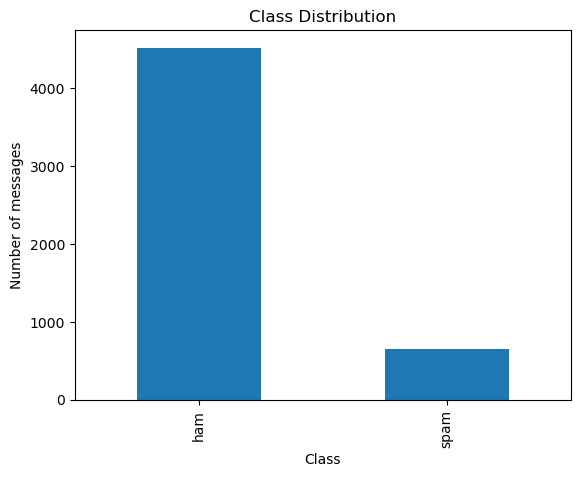

In [ ]:
print("Label distribution:")
print(df["label"].value_counts())

df["label"].value_counts().plot(kind="bar")
plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of messages")
plt.show()

## 5. בדיקת התפלגות המחלקות

כאן אנחנו בודקים כמה הודעות יש מכל סוג.

הבדיקה הזאת חשובה כי בדאטה סטים של ספאם בדרך כלל יש יותר הודעות רגילות מאשר הודעות ספאם.

אם הנתונים לא מאוזנים, Accuracy יכול להיות מדד מטעה.  
לכן בהמשך נסתכל בעיקר על F1-score עבור מחלקת `spam`.

## 6. ניקוי טקסט

לפני שנאמן את המודל, צריך לנקות את הטקסט.

בשלב הזה אנחנו מבצעים כמה פעולות פשוטות:

- המרה לאותיות קטנות
- הסרת סימני פיסוק
- הסרת מילים נפוצות באנגלית

המטרה היא להשאיר בטקסט בעיקר מילים שיכולות לעזור למודל להבדיל בין הודעה רגילה להודעת ספאם.

In [ ]:
stop_words = set(ENGLISH_STOP_WORDS)

def clean_text(text):
    text = str(text).lower()
    text = text.translate(str.maketrans("", "", string.punctuation))
    
    words = text.split()
    words = [word for word in words if word not in stop_words]
    
    return " ".join(words)

df["cleaned_text"] = df["text"].apply(clean_text)

display(df[["text", "cleaned_text", "label"]].head())

,text,cleaned_text,label
0,"Go until jurong point, crazy.. Available only ...",jurong point crazy available bugis n great wor...,ham
1,Ok lar... Joking wif u oni...\n,ok lar joking wif u oni,ham
2,Free entry in 2 a wkly comp to win FA Cup fina...,free entry 2 wkly comp win fa cup final tkts 2...,spam
3,U dun say so early hor... U c already then say...,u dun say early hor u c say,ham
4,"Nah I don't think he goes to usf, he lives aro...",nah dont think goes usf lives,ham


## 7. מימוש SimpleKNN

בשלב הזה אנחנו מממשים בעצמנו מודל KNN פשוט.

הרעיון של KNN הוא:

1. לקחת הודעה חדשה.
2. להשוות אותה להודעות בסט האימון.
3. למצוא את K ההודעות הכי דומות.
4. לקבוע את הסיווג לפי רוב השכנים.

מכיוון שאנחנו עובדים עם טקסט שמומר לווקטורים, השתמשנו ב-Cosine Similarity כדי למדוד דמיון בין הודעות.

In [ ]:
class SimpleKNN:
    def __init__(self, k=3):
        self.k = k
        self.X_train = None
        self.y_train = None
        self.classes_ = None

    def fit(self, X, y):
        self.X_train = X
        self.y_train = np.asarray(y)
        self.classes_ = np.unique(self.y_train)
        return self

    def predict_proba(self, X_test):
        similarities = cosine_similarity(X_test, self.X_train)
        probabilities = []

        for row in similarities:
            neighbor_indices = np.argsort(row)[-self.k:][::-1]
            neighbor_labels = self.y_train[neighbor_indices]

            class_probs = []

            for class_label in self.classes_:
                class_probs.append(np.mean(neighbor_labels == class_label))

            probabilities.append(class_probs)

        return np.array(probabilities)

    def predict(self, X_test):
        probabilities = self.predict_proba(X_test)
        return self.classes_[np.argmax(probabilities, axis=1)]

## 8. חלוקה ל-Train ו-Test

כאן אנחנו מחלקים את הנתונים לסט אימון ולסט בדיקה.

סט האימון ישמש לאימון המודל ולבחירת הפרמטרים.  
סט הבדיקה ישמש רק בסוף, כדי לבדוק את הביצועים של המודל הסופי.

השתמשנו ב-`stratify` כדי לשמור על יחס דומה בין `ham` ו-`spam` גם ב-train וגם ב-test.

In [ ]:
X = df["cleaned_text"]
y = df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train size:", len(X_train))
print("Test size:", len(X_test))

print("\nTrain label distribution:")
print(y_train.value_counts())

print("\nTest label distribution:")
print(y_test.value_counts())

Train size: 4136
Test size: 1035

Train label distribution:
label
ham     3614
spam     522
Name: count, dtype: int64

Test label distribution:
label
ham     904
spam    131
Name: count, dtype: int64


## 9. איזון נתוני האימון

מכיוון שהנתונים לא מאוזנים, אנחנו מאזנים רק את סט האימון.

השתמשנו ב-Undersampling.

כלומר, הקטנו את מספר הודעות ה-`ham` בסט האימון כך שיהיה שווה למספר הודעות ה-`spam`.

את סט הבדיקה לא שינינו, כדי שהוא יישאר קרוב לנתונים המקוריים.

In [ ]:
train_df = pd.DataFrame({
    "text": X_train,
    "label": y_train
})

ham_train = train_df[train_df["label"] == "ham"]
spam_train = train_df[train_df["label"] == "spam"]

ham_train_under = resample(
    ham_train,
    replace=False,
    n_samples=len(spam_train),
    random_state=42
)

train_balanced = pd.concat([ham_train_under, spam_train])
train_balanced = train_balanced.sample(frac=1, random_state=42)

X_train_balanced = train_balanced["text"]
y_train_balanced = train_balanced["label"]

print("Original training distribution:")
print(y_train.value_counts())

print("\nBalanced training distribution:")
print(y_train_balanced.value_counts())

Original training distribution:
label
ham     3614
spam     522
Name: count, dtype: int64

Balanced training distribution:
label
spam    522
ham     522
Name: count, dtype: int64


## 10. ייצוג הטקסט כמספרים

מודל למידת מכונה לא יכול לעבוד ישירות עם טקסט, ולכן צריך להמיר את ההודעות למספרים.

בדקנו כמה שיטות:

- CountVectorizer
- TF-IDF עם מילים בודדות
- TF-IDF עם מילים בודדות וזוגות מילים
- TF-IDF עם SVD

המטרה היא לבדוק איזו שיטה עובדת הכי טוב עם מודל ה-KNN שלנו.

In [ ]:
vectorizer_configs = {
    "CountVectorizer": CountVectorizer(),
    "TfidfVectorizer_Unigram": TfidfVectorizer(),
    "TfidfVectorizer_Bigram": TfidfVectorizer(ngram_range=(1, 2)),
    "TfidfVectorizer_SVD100": make_pipeline(
        TfidfVectorizer(),
        TruncatedSVD(n_components=100, random_state=42)
    )
}

for name, vectorizer in vectorizer_configs.items():
    current_vectorizer = clone(vectorizer)
    X_vec = current_vectorizer.fit_transform(X_train_balanced)
    print(name, "shape:", X_vec.shape)

CountVectorizer shape: (1044, 3760)
TfidfVectorizer_Unigram shape: (1044, 3760)
TfidfVectorizer_Bigram shape: (1044, 11375)
TfidfVectorizer_SVD100 shape: (1044, 100)


## 11. Grid Search ידני עם 5-Fold Cross Validation

בשלב זה נבצע חיפוש ידני אחר השילוב הטוב ביותר.

נבדוק שילובים שונים של:

- שיטת ייצוג הטקסט
- ערך K במודל KNN

עבור כל שילוב נשתמש ב-5-Fold Cross Validation על סט האימון המאוזן.

המודל הסופי ייבחר לפי ממוצע F1-score עבור מחלקת `spam`.

In [ ]:
k_values = [3, 5, 7, 9]

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

X_cv = X_train_balanced.reset_index(drop=True)
y_cv = y_train_balanced.reset_index(drop=True)

grid_search_results = []

for vectorizer_name, vectorizer in vectorizer_configs.items():
    for k in k_values:
        fold_f1_spam_scores = []
        fold_f1_macro_scores = []

        for train_idx, val_idx in cv.split(X_cv, y_cv):
            X_fold_train = X_cv.iloc[train_idx]
            X_fold_val = X_cv.iloc[val_idx]
            y_fold_train = y_cv.iloc[train_idx]
            y_fold_val = y_cv.iloc[val_idx]

            current_vectorizer = clone(vectorizer)

            X_fold_train_vec = current_vectorizer.fit_transform(X_fold_train)
            X_fold_val_vec = current_vectorizer.transform(X_fold_val)

            knn = SimpleKNN(k=k)
            knn.fit(X_fold_train_vec, y_fold_train)

            y_pred = knn.predict(X_fold_val_vec)

            fold_f1_spam_scores.append(
                f1_score(y_fold_val, y_pred, pos_label="spam", zero_division=0)
            )

            fold_f1_macro_scores.append(
                f1_score(y_fold_val, y_pred, average="macro", zero_division=0)
            )

        grid_search_results.append({
            "Vectorizer": vectorizer_name,
            "K": k,
            "Mean_F1_Spam": np.mean(fold_f1_spam_scores),
            "Mean_F1_Macro": np.mean(fold_f1_macro_scores)
        })

grid_search_df = pd.DataFrame(grid_search_results)

grid_search_df = grid_search_df.sort_values(
    by="Mean_F1_Spam",
    ascending=False
).reset_index(drop=True)

display(grid_search_df)

,Vectorizer,K,Mean_F1_Spam,Mean_F1_Macro
0,TfidfVectorizer_Unigram,5,0.898666,0.899375
1,CountVectorizer,7,0.897952,0.895424
2,TfidfVectorizer_Bigram,5,0.897557,0.898411
3,TfidfVectorizer_Unigram,7,0.896359,0.896472
4,TfidfVectorizer_Bigram,7,0.895495,0.895520
5,TfidfVectorizer_Bigram,3,0.894809,0.896463
6,TfidfVectorizer_Unigram,3,0.889851,0.892526
7,CountVectorizer,5,0.888264,0.886890
8,CountVectorizer,3,0.887527,0.887818
9,TfidfVectorizer_SVD100,3,0.882105,0.880037


## 12. בחירת המודל הסופי

אחרי ה-Grid Search בחרנו את השילוב שנתן את התוצאה הכי טובה.

לאחר מכן אימנו את המודל הסופי על כל סט האימון המאוזן.

בסוף בדקנו את המודל על סט הבדיקה.

In [ ]:
best_result = grid_search_df.iloc[0]

best_vectorizer_name = best_result["Vectorizer"]
best_k = int(best_result["K"])

print("Best vectorizer:", best_vectorizer_name)
print("Best K:", best_k)

best_vectorizer = clone(vectorizer_configs[best_vectorizer_name])

X_train_best = best_vectorizer.fit_transform(X_train_balanced)
X_test_best = best_vectorizer.transform(X_test)

best_knn = SimpleKNN(k=best_k)
best_knn.fit(X_train_best, y_train_balanced)

y_test_pred = best_knn.predict(X_test_best)

print("\nClassification Report:")
print(classification_report(y_test, y_test_pred, zero_division=0))

print("F1 score for spam:")
print(f1_score(y_test, y_test_pred, pos_label="spam", zero_division=0))

Best vectorizer: TfidfVectorizer_Unigram
Best K: 5

Classification Report:
              precision    recall  f1-score   support

         ham       0.98      0.93      0.96       904
        spam       0.65      0.89      0.75       131

    accuracy                           0.93      1035
   macro avg       0.82      0.91      0.86      1035
weighted avg       0.94      0.93      0.93      1035

F1 score for spam:
0.7548387096774194


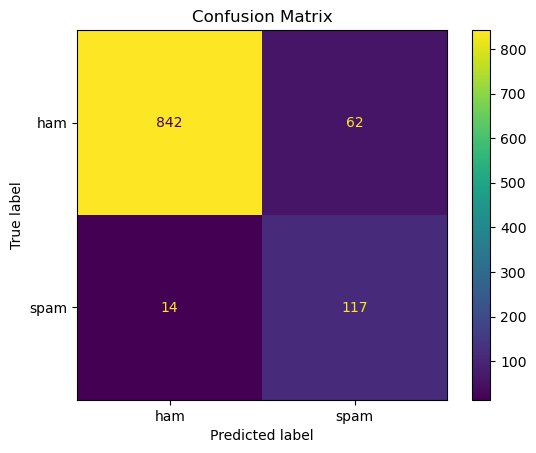

In [ ]:
cm = confusion_matrix(y_test, y_test_pred, labels=["ham", "spam"])

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["ham", "spam"]
)

disp.plot()
plt.title("Confusion Matrix")
plt.show()

## 13. דוגמאות לחיזויים

בשלב זה נציג כמה הודעות מתוך סט הבדיקה.

עבור כל הודעה נציג:

- הטקסט של ההודעה
- הסיווג האמיתי
- הסיווג שהמודל חזה
- ההסתברות שהמודל נתן לכך שמדובר בספאם

המטרה היא להבין בצורה פשוטה איך המודל מתנהג על דוגמאות אמיתיות.

In [ ]:
proba = best_knn.predict_proba(X_test_best)

spam_index = list(best_knn.classes_).index("spam")
spam_probabilities = proba[:, spam_index]

predictions_df = pd.DataFrame({
    "text": X_test.values,
    "true_label": y_test.values,
    "predicted_label": y_test_pred,
    "spam_probability": spam_probabilities
})

display(predictions_df.head(5))

,text,true_label,predicted_label,spam_probability
0,aight 8 latest probably closer 7 jay tyler jus...,ham,ham,0.0
1,ok arm feeling weak cuz got shot time,ham,ham,0.0
2,ladies genus second k,ham,spam,0.8
3,neva mind ok,ham,ham,0.0
4,todays vodafone numbers ending 4882 selected r...,spam,spam,1.0


## 14. הסבר פשוט להחלטת המודל

בשלב הזה ניסינו להסביר חיזוי אחד של המודל.

בדקנו אילו מילים הופיעו בהודעה, והאם הן יותר אופייניות להודעות ספאם או להודעות רגילות.

ערך חיובי אומר שהמילה יותר קשורה ל-`spam`.  
ערך שלילי אומר שהמילה יותר קשורה ל-`ham`.

זה הסבר פשוט, ולא שיטת Explainability מתקדמת.

Message for explanation:
ladies genus second k


,token,value,contribution
0,ladies,0.686507,0.000826
1,second,0.727124,-0.000438


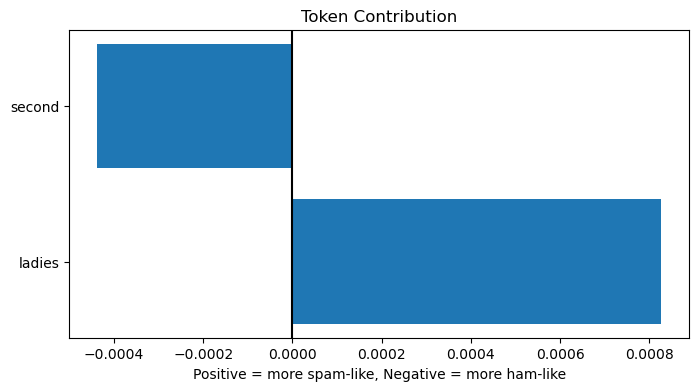

In [ ]:
if best_vectorizer_name == "TfidfVectorizer_SVD100":
    explanation_vectorizer = TfidfVectorizer(ngram_range=(1, 2))
    X_train_exp = explanation_vectorizer.fit_transform(X_train_balanced)
else:
    explanation_vectorizer = clone(vectorizer_configs[best_vectorizer_name])
    X_train_exp = explanation_vectorizer.fit_transform(X_train_balanced)

# נבחר הודעה שהמודל חזה כספאם אם קיימת כזו
spam_predictions = predictions_df[predictions_df["predicted_label"] == "spam"]

if len(spam_predictions) > 0:
    sample_text = spam_predictions.iloc[0]["text"]
else:
    sample_text = predictions_df.iloc[0]["text"]

print("Message for explanation:")
print(sample_text)

sample_vec = explanation_vectorizer.transform([sample_text])
feature_names = explanation_vectorizer.get_feature_names_out()

spam_mask = (y_train_balanced == "spam").values
ham_mask = (y_train_balanced == "ham").values

spam_mean = np.asarray(X_train_exp[spam_mask].mean(axis=0)).ravel()
ham_mean = np.asarray(X_train_exp[ham_mask].mean(axis=0)).ravel()

sample_array = sample_vec.toarray().ravel()
present_indices = np.where(sample_array > 0)[0]

token_rows = []

for idx in present_indices:
    token = feature_names[idx]
    value = sample_array[idx]
    contribution = value * (spam_mean[idx] - ham_mean[idx])

    token_rows.append({
        "token": token,
        "value": value,
        "contribution": contribution
    })

token_data = pd.DataFrame(token_rows)

if token_data.empty:
    print("No tokens found for explanation.")
else:
    token_data["abs_contribution"] = token_data["contribution"].abs()

    token_data = token_data.sort_values(
        by="abs_contribution",
        ascending=False
    ).head(10)

    display(token_data[["token", "value", "contribution"]].sort_values(
        by="contribution",
        ascending=False
    ))

    plt.figure(figsize=(8, 4))
    plt.barh(token_data["token"], token_data["contribution"])
    plt.axvline(0, color="black")
    plt.title("Token Contribution")
    plt.xlabel("Positive = more spam-like, Negative = more ham-like")
    plt.show()

## 15. מסקנות

בפרויקט הזה בנינו מודל פשוט לסיווג הודעות SMS.

בהתחלה טענו את הנתונים ובדקנו את התפלגות המחלקות.  
לאחר מכן ניקינו את הטקסט והמרנו אותו לייצוג מספרי.

מימשנו מודל KNN פשוט, ובדקנו כמה שיטות שונות לייצוג הטקסט.

בגלל שהנתונים לא מאוזנים, השתמשנו ב-Undersampling על סט האימון בלבד.

לאחר מכן השתמשנו ב-5-Fold Cross Validation כדי לבחור את המודל הטוב ביותר.

בסוף בדקנו את המודל על סט הבדיקה, והצגנו את התוצאות בעזרת Classification Report, F1-score ו-Confusion Matrix.

בסך הכול, ניתן לראות שגם מודל פשוט כמו KNN יכול לתת תוצאות סבירות כאשר מנקים את הטקסט ומייצגים אותו בצורה מתאימה.

## 16. קישורים להגשה

- **Dataset URL:** https://www.kaggle.com/datasets/thedevastator/sms-spam-collection-a-more-diverse-dataset/data
- **Repository URL:** https://github.com/RonHagani/sms-spam-classification-ml